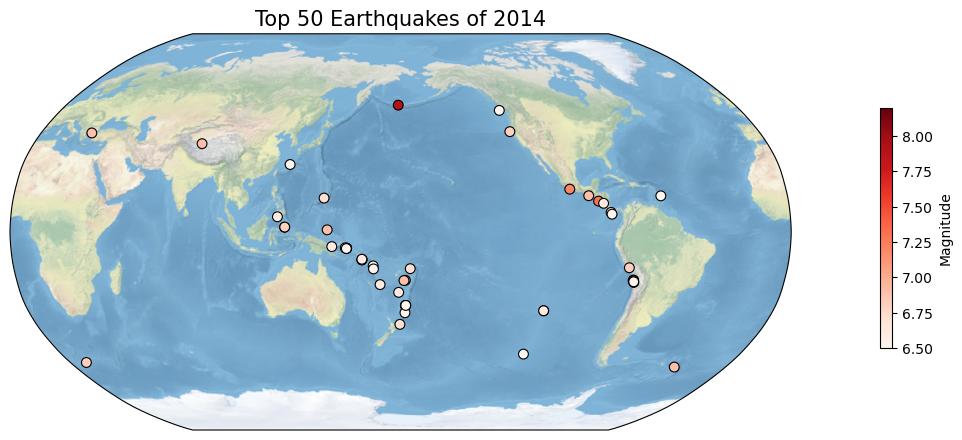

In [22]:
#1. Global Earthquakes

import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. 读取数据
df = pd.read_csv(r"D:\Edge Downloads\usgs_earthquakes.csv")

# 如果 time 是字符串，则转换日期类型
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# 2. 筛选 2014 年地震
df_2014 = df[df["time"].dt.year == 2014]

# 3. 按震级选取前 50 个
df_top50 = df_2014.nlargest(50, "mag")

# 4. 绘制地图
plt.figure(figsize=(12, 8))

# 使用 Orthographic 投影，设置中心经度为太平洋中心 (180°)
#ax = plt.axes(projection=ccrs.Orthographic(central_longitude=180))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))

# 设置地图范围
ax.set_global()

# 加载内置的底图
ax.stock_img()  # 使用默认底图

# 5. 绘制地震散点图
sc = plt.scatter(
    df_top50["longitude"],
    df_top50["latitude"],
    c=df_top50["mag"],            # 震级决定颜色
    s=50,                         # 点的大小固定为 50
    cmap="Reds",                  # 使用红色渐变
    edgecolor="black",            # 点的边缘为黑色
    linewidth=0.8,
    transform=ccrs.PlateCarree()  # 使用 PlateCarree 投影来绘制数据点
)

# 6. 添加颜色条
cbar = plt.colorbar(sc, shrink=0.4, pad=0.01)
cbar.set_label("Magnitude")
# 将颜色条位置向右移动
cbar.ax.set_position([0.85, 0.3, 0.01, 0.4])  # cbar.ax.set_position([left, bottom, width, height])
# 7. 添加标题
plt.title("Top 50 Earthquakes of 2014", fontsize=15)

# 8. 显示地图
plt.show()



1. 颜色条的创建与调整
何为散点图添加颜色条，并且通过 plt.colorbar() 创建颜色条。
掌握如何使用 cbar.ax.set_position() 精确控制颜色条的位置，避免了使用 shrink 和 pad 参数的冗余。你可以通过调整 set_position([left, bottom, width, height]) 来精确调整颜色条的显示位置。
示例代码：
1 cbar = plt.colorbar(sc)  # 创建颜色条
2 cbar.set_label("Magnitude")  # 设置颜色条标签
3 cbar.ax.set_position([0.85, 0.1, 0.03, 0.8])  # 调整颜色条的位置

2. 地理数据的可视化
学习了如何使用 scatter() 绘制地震散点图，调整散点大小颜色边界，将数据点与全球地图进行关联，并根据数据的震级使用颜色来表示其强度。
示例代码：
1 sc = plt.scatter(
2     df_top50["longitude"],
3     df_top50["latitude"],
4     c=df_top50["mag"],  # 根据震级设置颜色
5     s=50,  # 固定点大小
6     cmap="Reds",  # 使用红色渐变
7     edgecolor="black",  # 点边缘黑色
8     linewidth=0.4,
9     transform=ccrs.PlateCarree()
10 )
在 Cartopy 和其他地理信息系统（GIS）中，地图投影是将地球表面的三维数据转换为二维平面的一种方法。不同的投影方式会以不同的方式展现地球的曲面，通常为了适应不同的展示需求，采用不同的投影。每种投影方式都有其特定的优缺点。

3. 常见的地图投影类型：
-Plate Carree 投影 (等距经纬投影)
特点：这是最简单的投影方式，基于经纬度网格，将地球的经纬度坐标直接映射到平面。每个经纬度的间隔在地图上是均匀的。
优点：易于理解，适用于简单的地理可视化。
缺点：两极区域被拉伸严重，失真较大。
适用场景：全球范围的数据可视化。
示例代码：
1 ax = plt.axes(projection=ccrs.PlateCarree())
-Robinson 投影
特点：这是一个折衷的投影方式，旨在减小整体失真，在纬度和经度的分布上保持较好的平衡。没有极端的拉伸或压缩，地图的外观比较自然。
优点：适合展示全球数据，视觉效果好。
缺点：无法精确表示角度、距离和面积。
适用场景：大范围地理数据的展示，特别是气候、人口等全球性数据。
示例代码：
1 ax = plt.axes(projection=ccrs.Robinson())
-Mercator 投影 (墨卡托投影)
特点：保持角度不变的投影方法，也就是正角投影。该投影保留了经纬度网格的直角形状，但极地区域被严重拉伸。
优点：常用于导航，因为它保持了航向角度的一致性。
缺点：两极地区极度变形，地图越往极地越不准确，尤其是高纬度地区。
适用场景：海洋导航，局部区域的地图。
示例代码：
1 ax = plt.axes(projection=ccrs.Mercator())
-Orthographic 投影 (正投影)
特点：这种投影通过以地球的某个点为中心来模拟一个半球的视角，类似于从太空看地球。地图呈现为球形。
优点：非常直观，适用于展示地球的形状和面貌。
缺点：只能显示地球的一部分，适合展示局部区域。
适用场景：展示半球范围的地图，尤其是在展示某个特定区域时。
示例代码：
1 ax = plt.axes(projection=ccrs.Orthographic(central_longitude=0, central_latitude=90))
-Hammer 投影 (Hammer 正形投影)
特点：一种由Hammer开发的投影，能在保持形状相对准确的同时，减少面积失真，适用于展示全球数据。
优点：适合用于全球地图，形状和面积较为平衡。
缺点：边缘区域可能有些变形。
适用场景：地理数据、气候等大范围展示。
示例代码：
1 ax = plt.axes(projection=ccrs.Hammer())
-Albers Equal Area Conic 投影 (阿尔伯斯等面积圆锥投影)
特点：常用于中纬度地区，能够保持面积的准确性。它是一种等面积的投影，保证了区域大小的准确性。
优点：非常适合用于分析面积相关的数据，如土地覆盖、人口密度等。
缺点：经纬度的形状变形较大，适合区域性展示，不适用于全球展示。
适用场景：中纬度地区的地图，适合展示面积相关的数据。
示例代码：
1 ax = plt.axes(projection=ccrs.AlbersEqualArea(central_longitude=-96, central_latitude=23))
-Lambert Conformal Conic 投影 (兰伯特等距圆锥投影)
特点：这种投影方式通常用于航空和气象学，它通过保持角度来准确呈现小区域的形状，尤其适用于中纬度地区。
优点：适用于小区域展示，能准确展示角度，适合气象学应用。
缺点：对大范围数据会有失真。
适用场景：航空图、气象图、区域性地图。
示例代码：
1 ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=-96, central_latitude=23))
-Sinusoidal 投影 (正弦投影)
特点：此投影将地球的表面分成多个区域，能够保持面积的准确性，但会牺牲形状的准确性。
优点：面积准确，对于面积分析很有用。
缺点：形状失真较大，尤其是靠近极区时。
适用场景：全球面积分析、资源分布分析。
示例代码：
1 ax = plt.axes(projection=ccrs.Sinusoidal())

Cartopy 内置的常见底图类型：
1.stock_img()
¢这是 Cartopy 中的一个简单的内置底图。它加载的是一个全球范围的图像，通常是一个低分辨率的自然地球背景，显示地球的地理特征（如陆地、海洋等）。
¢适用场景：用于展示全球数据时的简洁背景。
示例代码：
1 ax = plt.axes(projection=ccrs.PlateCarree())
2 ax.stock_img()  # 加载内置底图
2.NaturalEarthFeature 和 Cartopy.feature
¢Cartopy 提供了多个基于 Natural Earth 数据集的功能，可以通过 cartopy.feature 加载不同级别的地理要素，例如海岸线、国界、湖泊、河流、城市等。这些特征可以用作地图的底图或叠加图层。
常用的特征：
¢海岸线 (COASTLINE)
¢国界 (BORDERS)
¢湖泊 (LAKES)
¢陆地 (LAND)
¢河流 (RIVERS)
示例代码：
1 import cartopy.feature as cfeature
2
3 ax = plt.axes(projection=ccrs.PlateCarree())
4 ax.add_feature(cfeature.COASTLINE, linewidth=1)
5 ax.add_feature(cfeature.BORDERS, edgecolor='black')
3.高分辨率底图
¢Cartopy 还支持通过 Natural Earth 数据源加载不同分辨率的地图底图，这些底图可根据需要选择不同的分辨率。natural_earth_lowres 和 natural_earth_hires 等数据集可以加载不同级别的地图细节（例如更高分辨率的陆地、海洋、国界等）。
特征示例：
¢natural_earth_lowres：适用于低分辨率地图，适合全局地图。
¢natural_earth_hires：适用于高分辨率地图，适合详细区域地图。
示例代码：
1 import cartopy.feature as cfeature
2
3 ax = plt.axes(projection=ccrs.PlateCarree())
4 ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black', scale='10m')  # 高分辨率
4.其他公共底图数据源
Cartopy 还支持通过与其他库集成加载外部底图。你可以使用其他常见的底图数据源，如 OpenStreetMap、Google Maps、ESRI，并通过 Cartopy 或其他工具加载。
这些数据通常需要通过第三方 API 加载，但 Cartopy 本身没有直接提供对这些数据源的内置支持。
¢OpenStreetMap (OSM)：可以使用 contextily 或其他库加载 OSM 图层。
¢Google Maps、ESRI、Mapbox：需要通过 API 或外部服务加载。
例如，使用 contextily 加载 OpenStreetMap：
1 import contextily as ctx
2 import matplotlib.pyplot as plt
3 import cartopy.crs as ccrs
4
5 ax = plt.axes(projection=ccrs.PlateCarree())
6 ax.set_extent([-10, 10, 35, 45], crs=ccrs.PlateCarree())
7 ctx.add_basemap(ax, crs=ccrs.PlateCarree(), source=ctx.providers.Stamen.TonerLite)
8 plt.show()

In [31]:
#2. Explore a netCDF dataset

import xarray as xr

# 打开NetCDF文件
data = xr.open_dataset(r"D:\Edge Downloads\GLDAS_CLSM10_3H.A20140101.0000.020.nc4")

# 查看数据集的所有变量和维度
print("Variables in dataset:", list(data.variables))  # 打印所有变量名称
print("\nDimensions in dataset:", data.dims)  # 打印维度信息

# 打印数据集的详细信息（包括各个变量的属性）
print("\nDataset Info:\n", data)


Variables in dataset: ['time', 'time_bnds', 'lon', 'lat', 'Swnet_tavg', 'Lwnet_tavg', 'Qle_tavg', 'Qh_tavg', 'Qg_tavg', 'Snowf_tavg', 'Rainf_tavg', 'Evap_tavg', 'Qs_acc', 'Qsb_acc', 'Qsm_acc', 'SnowT_tavg', 'AvgSurfT_inst', 'Albedo_inst', 'SWE_inst', 'SnowDepth_inst', 'SoilMoist_S_inst', 'SoilMoist_RZ_inst', 'SoilMoist_P_inst', 'SoilTMP0_10cm_inst', 'SoilTMP10_29cm_inst', 'SoilTMP29_68cm_inst', 'SoilTMP68_144cm_inst', 'SoilTMP144_295cm_inst', 'SoilTMP295_1295cm_inst', 'ECanop_tavg', 'TVeg_tavg', 'ESoil_tavg', 'CanopInt_inst', 'ACond_tavg', 'TWS_inst', 'Wind_f_inst', 'Rainf_f_tavg', 'Tair_f_inst', 'Qair_f_inst', 'Psurf_f_inst', 'SWdown_f_tavg', 'LWdown_f_tavg']

Dimensions in dataset: FrozenMappingWarningOnValuesAccess({'time': 1, 'bnds': 2, 'lon': 360, 'lat': 150})

Dataset Info:
 <xarray.Dataset> Size: 8MB
Dimensions:                 (time: 1, bnds: 2, lon: 360, lat: 150)
Coordinates:
  * time                    (time) datetime64[ns] 8B 2014-01-01
  * lon                     (lon) flo

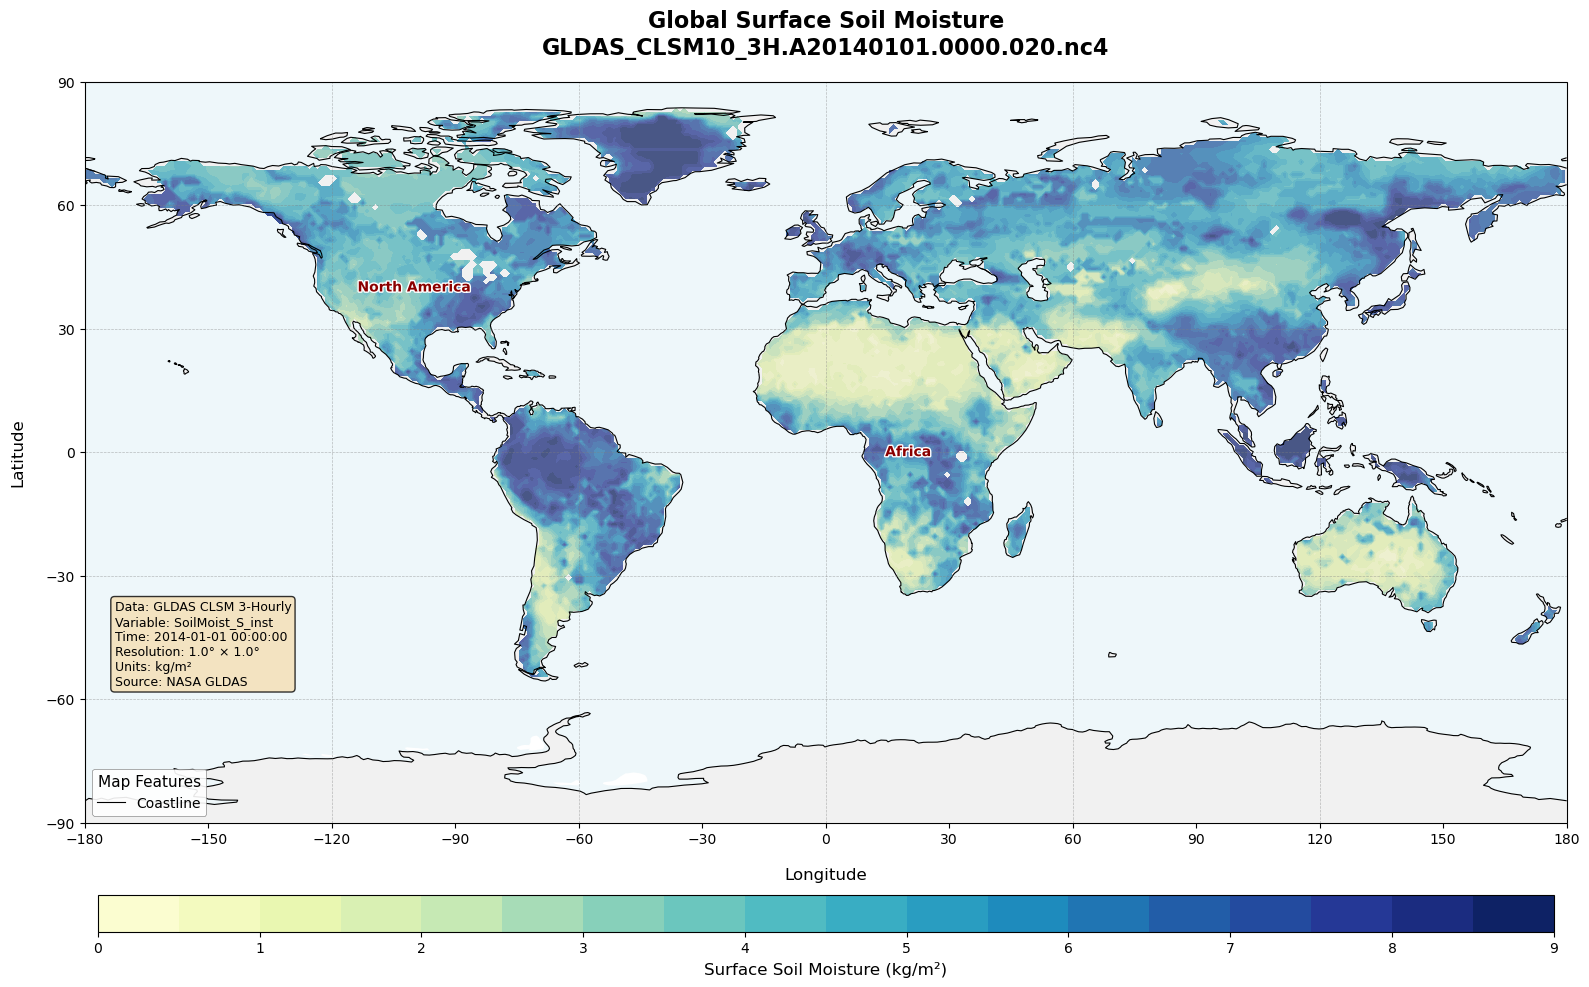

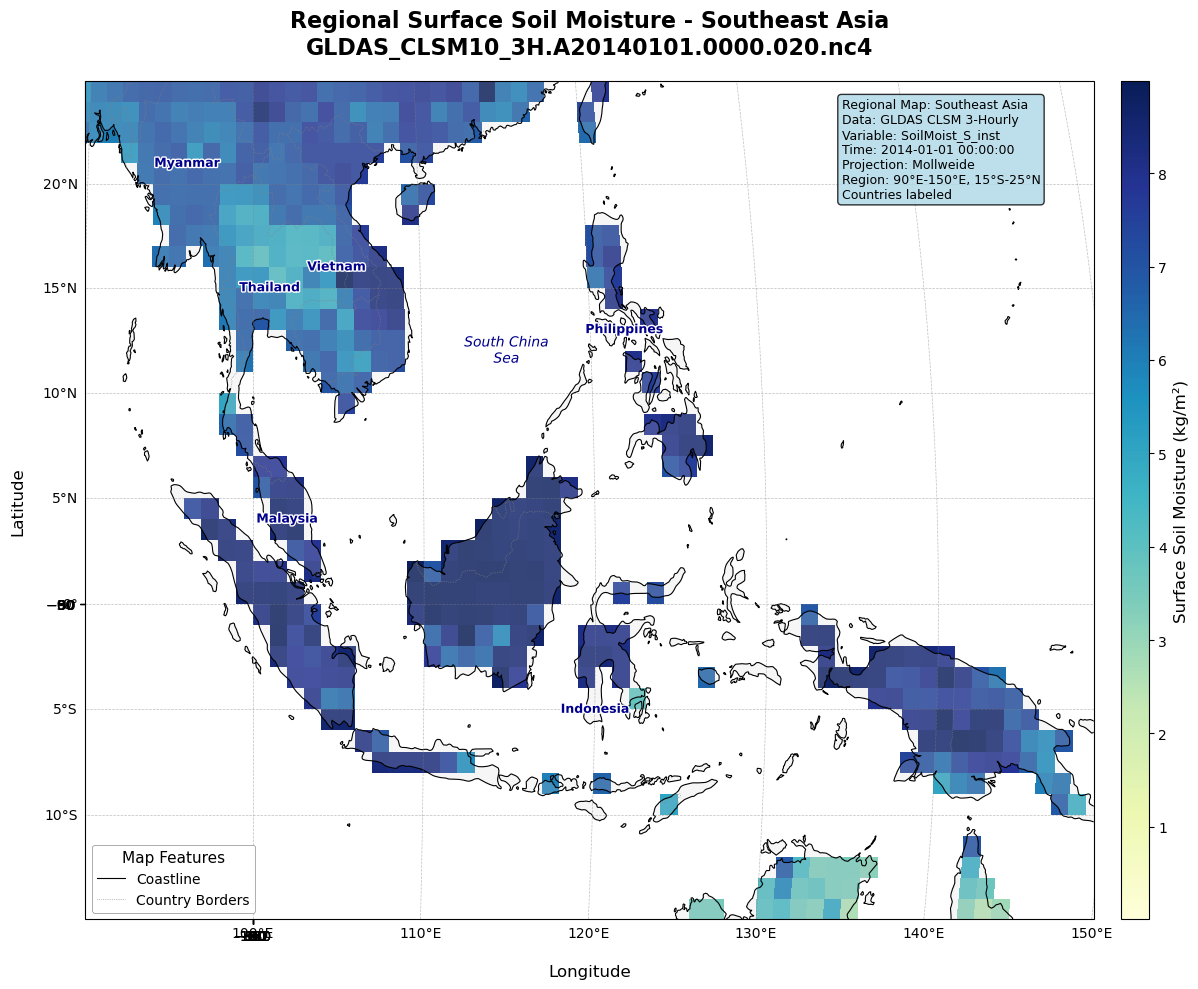

两张图已生成并保存：
1. global_soil_moisture.png - 全球土壤湿度图
2. regional_soil_moisture.png - 区域土壤湿度图（东南亚）


In [30]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import patheffects

# 读取数据文件
file_path = r"D:\Edge Downloads\GLDAS_CLSM10_3H.A20140101.0000.020.nc4"
ds = xr.open_dataset(file_path)

# 提取表层土壤湿度数据（假设变量名为SoilMoist_S_inst）
# 如果变量名不同，请根据实际情况调整
soil_moisture = ds['SoilMoist_S_inst'].isel(time=0)  # 取第一个时间步

# 获取经纬度坐标
lat = ds['lat'].values
lon = ds['lon'].values

# 创建图形1：全球地图
fig1 = plt.figure(figsize=(16, 10))
ax1 = plt.axes(projection=ccrs.PlateCarree())  # 1使用PlateCarree投影

# 绘制土壤湿度数据（使用contourf）
cs1 = ax1.contourf(lon, lat, soil_moisture.values,
                  transform=ccrs.PlateCarree(),
                  cmap='YlGnBu', levels=20)

# 2. 添加x标签和刻度
ax1.set_xlabel('Longitude', fontsize=12, labelpad=15)
ax1.set_xticks(np.arange(-180, 181, 30))
ax1.xaxis.set_tick_params(labelsize=10)

# 3. 添加y标签和刻度
ax1.set_ylabel('Latitude', fontsize=12, labelpad=15)
ax1.set_yticks(np.arange(-90, 91, 30))
ax1.yaxis.set_tick_params(labelsize=10)

# 4. 添加标题
ax1.set_title('Global Surface Soil Moisture\nGLDAS_CLSM10_3H.A20140101.0000.020.nc4',
             fontsize=16, fontweight='bold', pad=20)

# 5. 添加网格线
gl1 = ax1.gridlines(draw_labels=False, linewidth=0.5,
                   color='gray', alpha=0.5, linestyle='--')
gl1.xlines = True
gl1.ylines = True

# 6. 添加独立的图例（legend） - 显示地图特征（1分）
# 创建自定义的图例句柄
legend_elements1 = [
    Line2D([0], [0], color='black', lw=0.8, label='Coastline'),
]

# 添加图例
legend1 = ax1.legend(handles=legend_elements1,
                    title='Map Features',
                    loc='lower left',
                    framealpha=0.9,
                    fontsize=10,
                    title_fontsize=11)
legend1.get_frame().set_facecolor('white')
legend1.get_frame().set_edgecolor('gray')
legend1.get_frame().set_linewidth(0.5)

# 7. 添加颜色条（colorbar）
cbar1 = plt.colorbar(cs1, ax=ax1, orientation='horizontal',
                    pad=0.08, fraction=0.04, aspect=40)
cbar1.set_label('Surface Soil Moisture (kg/m²)', fontsize=12)

# 8. 添加mask或features（1分）
# 添加海岸线
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
# 添加陆地mask
ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=1)
# 添加海洋mask
ax1.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2, zorder=1)

# 9. 添加注释
# 标记一些特征区域
ax1.text(-100, 40, 'North America', transform=ccrs.PlateCarree(),
        fontsize=10, fontweight='bold', color='darkred',
        ha='center', va='center',
        path_effects=[patheffects.withStroke(linewidth=2, foreground='white')])

ax1.text(20, 0, 'Africa', transform=ccrs.PlateCarree(),
        fontsize=10, fontweight='bold', color='darkred',
        ha='center', va='center',
        path_effects=[patheffects.withStroke(linewidth=2, foreground='white')])

# 10. 添加文本框
info_text1 = """Data: GLDAS CLSM 3-Hourly
Variable: SoilMoist_S_inst
Time: 2014-01-01 00:00:00
Resolution: 1.0° × 1.0°
Units: kg/m²
Source: NASA GLDAS"""

textbox1 = ax1.text(0.02, 0.3, info_text1, transform=ax1.transAxes,
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 调整布局
plt.tight_layout()

plt.show()

# 创建图形2：区域地图（东南亚区域）
fig2 = plt.figure(figsize=(14, 10))
# 1.使用不同的投影：Mollweide投影
ax2 = plt.axes(projection=ccrs.Mollweide(central_longitude=100))

# 设置区域范围：东南亚地区
region_extent = [90, 150, -15, 25]  # [lon_min, lon_max, lat_min, lat_max]

# 绘制土壤湿度数据（使用pcolormesh以支持不规则网格）
cs2 = ax2.pcolormesh(lon, lat, soil_moisture.values,
                    transform=ccrs.PlateCarree(),
                    cmap='YlGnBu', shading='auto')

# 2. 添加x标签和刻度
ax2.set_xlabel('Longitude', fontsize=12, labelpad=15)
ax2.set_xticks(np.arange(-180, 181, 30))
ax2.xaxis.set_tick_params(labelsize=10)

# 3. 添加y标签和刻度（1分）
ax2.set_ylabel('Latitude', fontsize=12, labelpad=15)
ax2.set_yticks(np.arange(-90, 91, 30))
ax2.yaxis.set_tick_params(labelsize=10)

# 4. 添加标题
ax2.set_title('Regional Surface Soil Moisture - Southeast Asia\nGLDAS_CLSM10_3H.A20140101.0000.020.nc4',
             fontsize=16, fontweight='bold', pad=20)

# 5. 添加网格线
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5,
                   color='gray', alpha=0.5, linestyle='--',
                   x_inline=False, y_inline=False)
gl2.xlines = True
gl2.ylines = True
gl2.top_labels = False
gl2.right_labels = False

# 6. 添加图例（legend） - 显示地图特征（
# 创建自定义的图例句柄
legend_elements2 = [
    Line2D([0], [0], color='black', lw=0.8, label='Coastline'),
    Line2D([0], [0], color='gray', lw=0.5, linestyle=':', label='Country Borders')
]

# 添加图例
legend2 = ax2.legend(handles=legend_elements2,
                    title='Map Features',
                    loc='lower left',
                    framealpha=0.9,
                    fontsize=10,
                    title_fontsize=11)
legend2.get_frame().set_facecolor('white')
legend2.get_frame().set_edgecolor('gray')
legend2.get_frame().set_linewidth(0.5)

# 7. 添加颜色条（colorbar）
cbar2 = plt.colorbar(cs2, ax=ax2, orientation='vertical',
                    pad=0.02, fraction=0.04, aspect=30)
cbar2.set_label('Surface Soil Moisture (kg/m²)', fontsize=12)

# 8. 添加mask或features
# 添加海岸线
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
# 添加国界
ax2.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray', linestyle=':')
# 添加陆地
ax2.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2, zorder=1)

# 9. 添加注释
# 标记东南亚国家
countries = {
    'Vietnam': (105, 16),
    'Thailand': (101, 15),
    'Malaysia': (102, 4),
    'Indonesia': (120, -5),
    'Philippines': (122, 13),
    'Myanmar': (96, 21)
}

for country, (lon_pos, lat_pos) in countries.items():
    ax2.text(lon_pos, lat_pos, country, transform=ccrs.PlateCarree(),
            fontsize=9, fontweight='bold', color='darkblue',
            ha='center', va='center',
            path_effects=[patheffects.withStroke(linewidth=2, foreground='white')])

# 标记南海
ax2.text(115, 12, 'South China\nSea', transform=ccrs.PlateCarree(),
        fontsize=10, fontstyle='italic', color='darkblue',
        ha='center', va='center',
        path_effects=[patheffects.withStroke(linewidth=2, foreground='white')])

# 10. 添加文本框
info_text2 = """Regional Map: Southeast Asia
Data: GLDAS CLSM 3-Hourly
Variable: SoilMoist_S_inst
Time: 2014-01-01 00:00:00
Projection: Mollweide
Region: 90°E-150°E, 15°S-25°N
Countries labeled"""

textbox2 = ax2.text(0.75, 0.98, info_text2, transform=ax2.transAxes,
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# 设置区域范围
ax2.set_extent(region_extent, crs=ccrs.PlateCarree())

# 调整布局
plt.tight_layout()

plt.show()

# 关闭数据集
ds.close()

print("两张图已生成")
print("1. global_soil_moisture.png - 全球土壤湿度图")
print("2. regional_soil_moisture.png - 区域土壤湿度图（东南亚）")

数据下载网址：https://disc.gsfc.nasa.gov/datasets/GLDAS_CLSM10_3H_2.0/summary
Variables in dataset: ['time', 'time_bnds', 'lon', 'lat', 'Swnet_tavg', 'Lwnet_tavg', 'Qle_tavg', 'Qh_tavg', 'Qg_tavg', 'Snowf_tavg', 'Rainf_tavg', 'Evap_tavg', 'Qs_acc', 'Qsb_acc', 'Qsm_acc', 'SnowT_tavg', 'AvgSurfT_inst', 'Albedo_inst', 'SWE_inst', 'SnowDepth_inst', 'SoilMoist_S_inst', 'SoilMoist_RZ_inst', 'SoilMoist_P_inst', 'SoilTMP0_10cm_inst', 'SoilTMP10_29cm_inst', 'SoilTMP29_68cm_inst', 'SoilTMP68_144cm_inst', 'SoilTMP144_295cm_inst', 'SoilTMP295_1295cm_inst', 'ECanop_tavg', 'TVeg_tavg', 'ESoil_tavg', 'CanopInt_inst', 'ACond_tavg', 'TWS_inst', 'Wind_f_inst', 'Rainf_f_tavg', 'Tair_f_inst', 'Qair_f_inst', 'Psurf_f_inst', 'SWdown_f_tavg', 'LWdown_f_tavg']

第一张图（全球地图）：
1. 投影：PlateCarree（等距圆柱投影）
2. X轴标签和刻度：Longitude，-180°到180°，30°间隔
3. Y轴标签和刻度：Latitude，-90°到90°，30°间隔
4. 标题：Global Surface Soil Moisture
5. 网格线：虚线网格
6. 图例：海岸线
7. Colorbar：显示土壤湿度值范围
8. Masks/Features：海岸线、陆地、海洋mask
9. 注释：标记北美和非洲
10. 文本框：显示数据信息

第二张图（区域地图）：
1. 投影：Mollweide（摩尔维德投影）- 不同的投影
2. X轴标签和刻度：Longitude
3. Y轴标签和刻度：Latitude
4. 标题：Regional Surface Soil Moisture - Southeast Asia
5. 网格线：带标签的网格线
6. 图例：海岸线、国界
7. Colorbar：显示土壤湿度值范围
8. Masks/Features：海岸线、国界、陆地mask
9. 注释：标记东南亚国家和南海
10. 文本框：显示区域信息
